# Tiền xử lý dữ liệu Rượu Vang – Dự đoán Giá

**Pipeline gồm 9 bước:**
1. Load dữ liệu và tổng quan
2. Trích xuất thông tin từ tên biến
3. Loại cột không dùng để train
4. Parse các cột số từ định dạng dữ liệu chuỗi
5. Xử lý giá trị thiếu
6. Xử lý outlier trong `gia_num`
7. Log-transform biến mục tiêu
8. Mã hóa biến phân loại
9. Lưu dataset sạch



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import re

# 1. Load dữ liệu và tổng quan

In [ ]:
from google.colab import files

uploaded = files.upload()

if uploaded:
  fn = list(uploaded.keys())[0]
  print(f'Đã tải lên tệp "{fn}"')
  try:
    df_raw = pd.read_csv(fn)
    df = df_raw.copy()
    print(f"Kích thước ban đầu: {df.shape[0]} dòng × {df.shape[1]} cột")
  except Exception as e:
    print(f"Lỗi khi đọc tệp CSV: {e}")
else:
  print("Không có tệp nào được tải lên.")


Saving wines1.csv to wines1.csv
Đã tải lên tệp "wines1.csv"
Kích thước ban đầu: 1579 dòng × 9 cột


In [ ]:
FILE_PATH = 'wines1.csv'

df_raw = pd.read_csv(FILE_PATH)

df = df_raw.copy()
print(f"Kích thước ban đầu: {df.shape[0]} dòng × {df.shape[1]} cột")
print(f"\nCác cột: {df.columns.tolist()}")
df.head()

Kích thước ban đầu: 1579 dòng × 9 cột

Các cột: ['ten', 'gia', 'giong_nho', 'nha_san_xuat', 'quoc_gia', 'nong_do', 'dung_tich', 'loai_ruou', 'url']


,ten,gia,giong_nho,nha_san_xuat,quoc_gia,nong_do,dung_tich,loai_ruou,url
0,Rượu Vang Pháp Château Guion Barrail Bordeaux ...,NaN,Bordeaux Blend,Château Guion Barrail,Vang Pháp,13% ABV*,750ml,Rượu Vang Đỏ,https://winecellar.vn/ruou-vang-phap/chateau-g...
1,Rượu Vang Pháp Château La Coste Le Rouge 2023,NaN,Blend,Château La Coste,Vang Pháp,14% ABV*,750ml,Rượu Vang Đỏ,https://winecellar.vn/ruou-vang-phap/chateau-l...
2,Rượu Vang Pháp La Fiole Côtes Du Rhône Rouge P...,638.000 ₫,Blend,Père Anselme,Vang Pháp,14% ABV*,750ml,Rượu Vang Đỏ,https://winecellar.vn/ruou-vang-phap/la-fiole-...
3,Rượu Vang Pháp La Fiole Du Pape Châteauneuf-Du...,1.936.000 ₫,Blend,Père Anselme,Vang Pháp,14.5% ABV*,750ml,Rượu Vang Đỏ,https://winecellar.vn/ruou-vang-phap/la-fiole-...
4,Rượu Vang Pháp Domaine Faiveley Bourgogne Pino...,1.496.000 ₫,Pinot Noir,Domaine Faiveley,Vang Pháp,13% ABV*,750ml,Rượu Vang Đỏ,https://winecellar.vn/ruou-vang-phap/domaine-f...


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1579 entries, 0 to 1578
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   ten           1579 non-null   object
 1   gia           1575 non-null   object
 2   giong_nho     1578 non-null   object
 3   nha_san_xuat  1579 non-null   object
 4   quoc_gia      1578 non-null   object
 5   nong_do       1562 non-null   object
 6   dung_tich     1562 non-null   object
 7   loai_ruou     1579 non-null   object
 8   url           1579 non-null   object
dtypes: object(9)
memory usage: 111.2+ KB


In [ ]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
print("Giá trị thiếu:")
display(pd.DataFrame({'Missing': missing, 'Tỷ lệ (%)': missing_pct}).query('Missing > 0'))

Giá trị thiếu:


,Missing,Tỷ lệ (%)
gia,4,0.25
giong_nho,1,0.06
quoc_gia,1,0.06
nong_do,17,1.08
dung_tich,17,1.08


# 2. Trích xuất thông tin từ biến tên

In [ ]:
def extract_year(name):
    """Tìm năm sản xuất (4 chữ số trong khoảng 1900-2099)."""
    match = re.search(r'\b(19|20)\d{2}\b', str(name))
    return int(match.group()) if match else None

In [ ]:
# Danh sách các hạng rượu phổ biến (có thể mở rộng)
APPELLATIONS = [
    # Pháp
    r"Châteauneuf-Du-Pape",
    r"Côtes Du Rhône",
    r"Bourgogne",
    r"Mercurey",
    r"Bordeaux",
    r"Champagne",
    r"Alsace",
    r"Provence",
    r"Languedoc",
    # Ý
    r"Primitivo",
    r"Negroamaro",
    r"Barolo",
    r"Chianti",
    r"Amarone",
    r"Brunello",
    r"Prosecco",
    # Tây Ban Nha
    r"Rioja",
    r"Ribera Del Duero",
    r"Cava",
    # Khác
    r"Pinot Noir",
    r"Cabernet Sauvignon",
    r"Sauvignon Blanc",
    r"Chardonnay",
    r"Merlot",
    r"Syrah",
    r"Grenache",
]

appellation_pattern = re.compile(
    '|'.join(APPELLATIONS),
    flags=re.IGNORECASE
)

def extract_rank(name):
    """Trích xuất hạng/appellation từ tên rượu."""
    matches = appellation_pattern.findall(str(name))
    if matches:
        seen = []
        for m in matches:
            if m.title() not in seen:
                seen.append(m.title())
        return ', '.join(seen)
    return None

In [ ]:
df['nam_san_xuat'] = df['ten'].apply(extract_year)
df['hang_ruou']    = df['ten'].apply(extract_rank)

In [ ]:
df.head()

,ten,gia,giong_nho,nha_san_xuat,quoc_gia,nong_do,dung_tich,loai_ruou,url,nam_san_xuat,hang_ruou
0,Rượu Vang Pháp Château Guion Barrail Bordeaux ...,NaN,Bordeaux Blend,Château Guion Barrail,Vang Pháp,13% ABV*,750ml,Rượu Vang Đỏ,https://winecellar.vn/ruou-vang-phap/chateau-g...,2023.0,Bordeaux
1,Rượu Vang Pháp Château La Coste Le Rouge 2023,NaN,Blend,Château La Coste,Vang Pháp,14% ABV*,750ml,Rượu Vang Đỏ,https://winecellar.vn/ruou-vang-phap/chateau-l...,2023.0,None
2,Rượu Vang Pháp La Fiole Côtes Du Rhône Rouge P...,638.000 ₫,Blend,Père Anselme,Vang Pháp,14% ABV*,750ml,Rượu Vang Đỏ,https://winecellar.vn/ruou-vang-phap/la-fiole-...,2023.0,Côtes Du Rhône
3,Rượu Vang Pháp La Fiole Du Pape Châteauneuf-Du...,1.936.000 ₫,Blend,Père Anselme,Vang Pháp,14.5% ABV*,750ml,Rượu Vang Đỏ,https://winecellar.vn/ruou-vang-phap/la-fiole-...,NaN,Châteauneuf-Du-Pape
4,Rượu Vang Pháp Domaine Faiveley Bourgogne Pino...,1.496.000 ₫,Pinot Noir,Domaine Faiveley,Vang Pháp,13% ABV*,750ml,Rượu Vang Đỏ,https://winecellar.vn/ruou-vang-phap/domaine-f...,2023.0,"Bourgogne, Pinot Noir"


# 3. Loại cột không dùng để train

In [ ]:
DROP_COLS = ['ten', 'url']
df.drop(columns=[c for c in DROP_COLS if c in df.columns], inplace=True)
print(f"Còn lại: {df.columns.tolist()}")

Còn lại: ['gia', 'giong_nho', 'nha_san_xuat', 'quoc_gia', 'nong_do', 'dung_tich', 'loai_ruou', 'nam_san_xuat', 'hang_ruou']


# 4. Parse các cột số từ định dạng dữ liệu chuỗi

### a. Parse `gia` → `gia_num` (chuỗi VNĐ → float)


In [ ]:
print("Mẫu giá trị thô:", df['gia'].dropna().head(5).tolist())
df['gia_num'] = (
    df['gia']
    .str.replace(r'[^\d]', '', regex=True)
    .replace('', np.nan)
    .astype('float')
)
print(f"\nParse gia_num xong – Missing: {df['gia_num'].isna().sum()}")

df['gia_num'].describe().apply(lambda x: f'{x:,.0f}')

df = df.drop(columns=['gia'], errors='ignore')
print("\nĐã loại bỏ cột 'gia' gốc.")

Mẫu giá trị thô: ['638.000\xa0₫', '1.936.000\xa0₫', '1.496.000\xa0₫', '1.754.500\xa0₫', '1.270.500\xa0₫']

Parse gia_num xong – Missing: 4

Đã loại bỏ cột 'gia' gốc.



### b. Parse `nong_do` → `nong_do_num` ("13% ABV*" → 13.0)

In [ ]:
df['nong_do_num'] = (
    df['nong_do']
    .str.extract(r'([\d.]+)')[0]
    .astype('float')
)
print(f"Parse nong_do_num xong – Missing: {df['nong_do_num'].isna().sum()}")

print(df['nong_do_num'].describe().round(2))

df = df.drop(columns=['nong_do'], errors='ignore')
print("\nĐã loại bỏ cột 'nong_do' gốc.")

Parse nong_do_num xong – Missing: 17
count    1562.00
mean       13.36
std         1.85
min         0.00
25%        13.00
50%        13.50
75%        14.00
max        20.00
Name: nong_do_num, dtype: float64

Đã loại bỏ cột 'nong_do' gốc.



### c. Parse `dung_tich` → `dung_tich_ml` ("1.5L" → 1500)

In [ ]:
def parse_dung_tich(val):
    """Chuyển chuỗi dung tích về đơn vị ml (lấy phần tử đầu nếu nhiều giá trị)."""
    if pd.isna(val):
        return np.nan
    val = str(val).split(',')[0].strip().lower()
    if 'ml' in val:
        return float(val.replace('ml', '').strip())
    elif 'l' in val:
        return float(val.replace('l', '').strip()) * 1000
    return np.nan

df['dung_tich_ml'] = df['dung_tich'].apply(parse_dung_tich)
print(f"Parse dung_tich_ml xong – Missing: {df['dung_tich_ml'].isna().sum()}")

print("\nPhân phối dung tích (ml):")
print(df['dung_tich_ml'].value_counts())

df = df.drop(columns=['dung_tich'], errors='ignore')
print("\nĐã loại bỏ cột 'dung_tich' gốc.")

Parse dung_tich_ml xong – Missing: 17

Phân phối dung tích (ml):
dung_tich_ml
750.0      1455
1500.0       41
3000.0       34
6000.0       10
5000.0        8
500.0         4
9000.0        3
375.0         3
12000.0       2
620.0         1
15000.0       1
Name: count, dtype: int64

Đã loại bỏ cột 'dung_tich' gốc.



# 5. Xử lý giá trị thiếu

In [ ]:
print("Giá trị thiếu TRƯỚC khi xử lý:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Giá trị thiếu TRƯỚC khi xử lý:
giong_nho          1
quoc_gia           1
nam_san_xuat     405
hang_ruou       1215
gia_num            4
nong_do_num       17
dung_tich_ml      17
dtype: int64


In [ ]:
# ── gia_num: xóa dòng ──
n_before = len(df)
df.dropna(subset=['gia_num'], inplace=True)
print(f"Xóa {n_before - len(df)} dòng thiếu gia_num. Còn: {len(df)} dòng.")

# ── nong_do_num: Điền giá trị thiếu bằng median ──
median_nong_do = df['nong_do_num'].median()
df['nong_do_num'] = df['nong_do_num'].fillna(median_nong_do)
print(f"Điền giá trị thiếu của nong_do_num = {median_nong_do} (median)")

# ── dung_tich_ml: Điền giá tri thiếu bằng mode(750ml chiếm >90%) ──
mode_dung_tich = df['dung_tich_ml'].mode()[0]
df['dung_tich_ml'] = df['dung_tich_ml'].fillna(mode_dung_tich)
print(f"Điền giá trị thiếu của cột dung_tich_ml = {mode_dung_tich} (mode)")

# ── giong_nho, quoc_gia: Thay điền Unknown bằng cách gán ──
for col in ['giong_nho', 'quoc_gia', 'hang_ruou']:
    if col in df.columns and df[col].isna().sum() > 0:
        df[col] = df[col].fillna('Unknown')
        print(f"Điền 'Unknown' cho {col}")

print("\nGiá trị thiếu SAU khi xử lý:")
remaining = df.isnull().sum()[df.isnull().sum() > 0]
print(remaining if len(remaining) > 0 else "→ Không còn giá trị thiếu ✓")

Xóa 4 dòng thiếu gia_num. Còn: 1575 dòng.
Điền giá trị thiếu của nong_do_num = 13.5 (median)
Điền giá trị thiếu của cột dung_tich_ml = 750.0 (mode)
Điền 'Unknown' cho giong_nho
Điền 'Unknown' cho quoc_gia
Điền 'Unknown' cho hang_ruou

Giá trị thiếu SAU khi xử lý:
nam_san_xuat    405
dtype: int64


In [ ]:
import datetime

df['Year_is_Null'] = (~df['nam_san_xuat'].isnull()).astype(int)

# Điền giá trị thiếu của nam_san_xuat bằng 0
df['nam_san_xuat'] = df['nam_san_xuat'].fillna(0)
print("Đã điền giá trị thiếu của nam_san_xuat bằng 0.")

# Biến đổi cột nam_san_xuat thành tuổi
current_year = datetime.datetime.now().year
df['tuoi'] = df['nam_san_xuat'].apply(lambda x: current_year - x if x > 0 else np.nan)
print(f"Đã biến đổi cột 'nam_san_xuat' thành cột 'tuoi' dựa trên năm hiện tại ({current_year}).")

df.drop(columns=['nam_san_xuat'], inplace=True)
print("Đã xóa cột 'nam_san_xuat' gốc.")

print("\nGiá trị thiếu SAU khi xử lý (nam_san_xuat và tuổi):")
remaining = df.isnull().sum()[df.isnull().sum() > 0]
print(remaining if len(remaining) > 0 else "→ Không còn giá trị thiếu ✓")

Đã điền giá trị thiếu của nam_san_xuat bằng 0.
Đã biến đổi cột 'nam_san_xuat' thành cột 'tuoi' dựa trên năm hiện tại (2026).
Đã xóa cột 'nam_san_xuat' gốc.

Giá trị thiếu SAU khi xử lý (nam_san_xuat và tuổi):
tuoi    405
dtype: int64


In [ ]:
df['tuoi'] = df['tuoi'].fillna(0)
print("Đã điền giá trị 0 cho các giá trị NaN trong cột 'tuoi'.")

print("\nGiá trị thiếu SAU khi xử lý (tuoi):")
remaining = df.isnull().sum()[df.isnull().sum() > 0]
print(remaining if len(remaining) > 0 else "→ Không còn giá trị thiếu ✓")

Đã điền giá trị 0 cho các giá trị NaN trong cột 'tuoi'.

Giá trị thiếu SAU khi xử lý (tuoi):
→ Không còn giá trị thiếu ✓


In [ ]:
df.head(10)


,giong_nho,nha_san_xuat,quoc_gia,loai_ruou,hang_ruou,gia_num,nong_do_num,dung_tich_ml,Year_is_Null,tuoi
2,Blend,Père Anselme,Vang Pháp,Rượu Vang Đỏ,Côtes Du Rhône,638000.0,14.0,750.0,1,3.0
3,Blend,Père Anselme,Vang Pháp,Rượu Vang Đỏ,Châteauneuf-Du-Pape,1936000.0,14.5,750.0,0,0.0
4,Pinot Noir,Domaine Faiveley,Vang Pháp,Rượu Vang Đỏ,"Bourgogne, Pinot Noir",1496000.0,13.0,750.0,1,3.0
5,Pinot Noir,Domaine Faiveley,Vang Pháp,Rượu Vang Đỏ,Mercurey,1754500.0,13.5,750.0,1,3.0
6,Primitivo,San Marzano,Vang Ý (Italy),Rượu Vang Đỏ,Primitivo,1270500.0,14.0,750.0,0,0.0
7,Negroamaro,San Marzano,Vang Ý (Italy),Rượu Vang Đỏ,Negroamaro,1270500.0,15.0,750.0,0,0.0
8,Negroamaro,San Marzano,Vang Ý (Italy),Rượu Vang Đỏ,Unknown,2035000.0,15.0,750.0,0,0.0
9,Primitivo,San Marzano,Vang Ý (Italy),Rượu Vang Đỏ,Unknown,2057000.0,15.5,750.0,0,0.0
10,Negroamaro,San Marzano,Vang Ý (Italy),Rượu Vang Đỏ,Negroamaro,599500.0,13.5,750.0,0,0.0
11,Primitivo,San Marzano,Vang Ý (Italy),Rượu Vang Đỏ,Primitivo,665500.0,13.5,750.0,0,0.0



# 6. Xử lý outlier trong `gia_num`

In [ ]:
Q1, Q3 = df['gia_num'].quantile([0.25, 0.75])
IQR = Q3 - Q1
lower = max(0, Q1 - 1.5 * IQR)
upper = Q3 + 1.5 * IQR

n_outliers = ((df['gia_num'] < lower) | (df['gia_num'] > upper)).sum()
print(f"Ngưỡng dưới : {lower:,.0f} ₫")
print(f"Ngưỡng trên : {upper:,.0f} ₫")
print(f"Số outlier   : {n_outliers} ({n_outliers/len(df)*100:.1f}%)")

n_before_outlier_removal = len(df)
df = df[((df['gia_num'] >= lower) & (df['gia_num'] <= upper))]
print(f"\nĐã loại bỏ {n_before_outlier_removal - len(df)} dòng chứa outlier trong gia_num.")
print(f"Còn lại {len(df)} dòng.")
print("\nSau khi loại bỏ outlier:")
print(df['gia_num'].describe().apply(lambda x: f'{x:,.0f}'))

Ngưỡng dưới : 0 ₫
Ngưỡng trên : 17,121,500 ₫
Số outlier   : 152 (9.7%)

Đã loại bỏ 152 dòng chứa outlier trong gia_num.
Còn lại 1423 dòng.

Sau khi loại bỏ outlier:
count         1,423
mean      4,316,247
std       4,009,075
min         231,000
25%       1,331,000
50%       2,772,000
75%       6,083,000
max      17,022,500
Name: gia_num, dtype: object


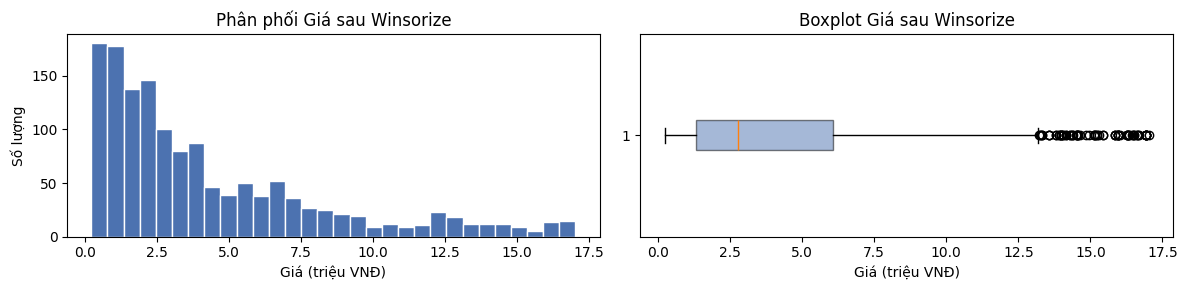

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3))
axes[0].hist(df['gia_num'] / 1e6, bins=30, color='#4C72B0', edgecolor='white')
axes[0].set_xlabel('Giá (triệu VNĐ)')
axes[0].set_ylabel('Số lượng')
axes[0].set_title('Phân phối Giá sau Winsorize')
axes[1].boxplot(df['gia_num'] / 1e6, vert=False, patch_artist=True,
                boxprops=dict(facecolor='#4C72B0', alpha=0.5))
axes[1].set_xlabel('Giá (triệu VNĐ)')
axes[1].set_title('Boxplot Giá sau Winsorize')
plt.tight_layout()
plt.show()

# 7. Log-transform biến mục tiêu

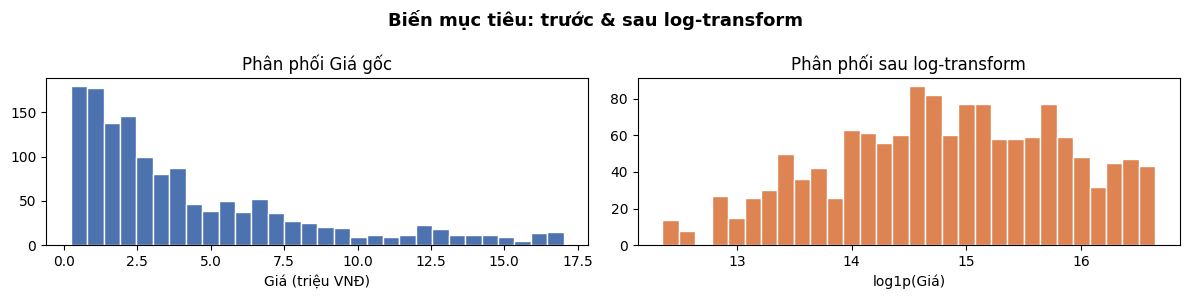

Skewness trước: 1.382
Skewness sau  : -0.204


In [ ]:
df['log_gia'] = np.log1p(df['gia_num'])

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
axes[0].hist(df['gia_num'] / 1e6, bins=30, color='#4C72B0', edgecolor='white')
axes[0].set_xlabel('Giá (triệu VNĐ)')
axes[0].set_title('Phân phối Giá gốc')
axes[1].hist(df['log_gia'], bins=30, color='#DD8452', edgecolor='white')
axes[1].set_xlabel('log1p(Giá)')
axes[1].set_title('Phân phối sau log-transform')
plt.suptitle('Biến mục tiêu: trước & sau log-transform', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Skewness trước: {df['gia_num'].skew():.3f}")
print(f"Skewness sau  : {df['log_gia'].skew():.3f}")

# 8. Mã hóa biến phân loại

In [ ]:
# ── One-Hot Encoding cho cột ít nhóm ──
# loai_ruou (6), quoc_gia (11) → One-hot Encoding
OHE_COLS = [c for c in ['hang_ruou','loai_ruou', 'quoc_gia'] if c in df.columns]

df = pd.get_dummies(df, columns=OHE_COLS, drop_first=True, dtype=int)
print(f"OHE xong cho: {OHE_COLS}")
print(f"Shape sau OHE: {df.shape}")

OHE xong cho: ['hang_ruou', 'loai_ruou', 'quoc_gia']
Shape sau OHE: (1423, 52)


# 9. Lưu dataset sạch

In [ ]:
output_file_name = 'processed_wine_data.csv'
df.to_csv(output_file_name, index=False)
print(f"DataFrame đã được xuất thành công ra tệp '{output_file_name}'")

DataFrame đã được xuất thành công ra tệp 'processed_wine_data.csv'


In [ ]:
df.head(10)

,giong_nho,nha_san_xuat,gia_num,nong_do_num,dung_tich_ml,Year_is_Null,tuoi,log_gia,hang_ruou_Amarone,hang_ruou_Barolo,...,quoc_gia_Vang Bồ Đào Nha,quoc_gia_Vang Chile,quoc_gia_Vang Hungary,quoc_gia_Vang Mỹ,quoc_gia_Vang New Zealand,quoc_gia_Vang Pháp,quoc_gia_Vang Tây Ban Nha,quoc_gia_Vang Úc,quoc_gia_Vang Ý (Italy),quoc_gia_Vang Đức
2,Blend,Père Anselme,638000.0,14.0,750.0,1,3.0,13.366095,0,0,...,0,0,0,0,0,1,0,0,0,0
3,Blend,Père Anselme,1936000.0,14.5,750.0,0,0.0,14.476135,0,0,...,0,0,0,0,0,1,0,0,0,0
4,Pinot Noir,Domaine Faiveley,1496000.0,13.0,750.0,1,3.0,14.218306,0,0,...,0,0,0,0,0,1,0,0,0,0
5,Pinot Noir,Domaine Faiveley,1754500.0,13.5,750.0,1,3.0,14.377695,0,0,...,0,0,0,0,0,1,0,0,0,0
6,Primitivo,San Marzano,1270500.0,14.0,750.0,0,0.0,14.054922,0,0,...,0,0,0,0,0,0,0,0,1,0
7,Negroamaro,San Marzano,1270500.0,15.0,750.0,0,0.0,14.054922,0,0,...,0,0,0,0,0,0,0,0,1,0
8,Negroamaro,San Marzano,2035000.0,15.0,750.0,0,0.0,14.526007,0,0,...,0,0,0,0,0,0,0,0,1,0
9,Primitivo,San Marzano,2057000.0,15.5,750.0,0,0.0,14.536760,0,0,...,0,0,0,0,0,0,0,0,1,0
10,Negroamaro,San Marzano,599500.0,13.5,750.0,0,0.0,13.303853,0,0,...,0,0,0,0,0,0,0,0,1,0
11,Primitivo,San Marzano,665500.0,13.5,750.0,0,0.0,13.408295,0,0,...,0,0,0,0,0,0,0,0,1,0
